# 🧠 Stroke Risk Predictor
###  ML Pipeline (6 Algorithms Compared)

**What are we building?**
A model that looks at a patient's basic health info (age, glucose level, BMI, smoking, etc.) and predicts: **is there a risk of stroke or not**.

**Real market use:** This type of model is used in preventive-healthcare apps and insurance risk-screening tools.

**Dataset:** [Stroke Prediction Dataset by fedesoriano — Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

> ⚠️ **Disclaimer:** This is an educational/portfolio project, not for real medical diagnosis.

---
Every step in this notebook is explained **slowly, in simple language** — no cell moves forward without first explaining "why we're doing this".


## 📖 First: Understand the Key Terms (Glossary)

Before moving ahead, let's understand these terms — we'll use them again and again:

| Term | Simple Meaning |
|---|---|
| **Feature** | A column given to the model as input (e.g., age, bmi) |
| **Target** | The column we want to predict (here: `stroke` — 0 or 1) |
| **Train/Test Split** | Splitting data into 2 parts: the model learns from one (train), and we check how well it learned on the other (test) |
| **Missing Values** | Empty/blank cells in the data — these need to be filled in |
| **Scaling** | Bringing numbers into the same range (e.g., 0-1), so no feature seems "more important" just because of its large value |
| **Encoding** | Converting text categories (like "Male"/"Female") into numbers, since the model only understands numbers |
| **Pipeline** | A chain of steps — data automatically passes from one step to the next (like a factory assembly line) |
| **Imbalanced Data** | When one class (here: stroke=1) is much rarer than the other — the model can start ignoring it |
| **SMOTE** | A technique that creates new "similar" synthetic examples of the minority class (the rarer one), to balance things out |
| **Overfitting** | When the model "memorizes" the training data but fails on new data |
| **Accuracy** | What % it predicted correctly (but can be misleading with imbalanced data!) |
| **Recall** | Out of all the actual stroke cases, how many did the model catch (this matters most in healthcare) |
| **Precision** | Out of all the times it said "stroke", how many were actually stroke |
| **F1 Score** | A balance between Precision and Recall |
| **ROC-AUC** | How well the model differentiates between the two classes (1.0 = perfect, 0.5 = random guessing) |

That's enough for now — the rest will be explained along with the code.


## 1️⃣ Setup — Installing and Importing Libraries

The line below will install all the tools we need. `xgboost` and `imbalanced-learn` are extra libraries that usually aren't pre-installed.


In [2]:
# Installing these libraries (if not already installed)
!pip install kaggle xgboost imbalanced-learn -q


In [3]:
# For handling data
import os
import numpy as np
import pandas as pd

# For making graphs/charts
import matplotlib.pyplot as plt
import seaborn as sns

# For splitting data and building the pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 6 different algorithms we'll try
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# For evaluating the model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# For handling imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# For saving the model to a file
import joblib

# Setting the seed - so results are the same every time (reproducibility)
np.random.seed(42)

print("All libraries imported! Let's move on.")


All libraries imported! Let's move on.


## 2️⃣ Read Data set 

1. This data set is loaded in local pc laptop you can copy dataset from data folder and paste it into below path


In [4]:
# Let's look at the first 5 rows - to see what the data looks like
df = pd.read_csv("G:\ML-Projects\stroke-risk-predictor\data\healthcare-dataset-stroke-data.csv")
df.head()


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Waseem\AppData\Local\Temp\ipykernel_37152\817337928.py:2: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv("G:\ML-Projects\stroke-risk-predictor\data\healthcare-dataset-stroke-data.csv")


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3️⃣ EDA (Understanding the Data)

Before building a model, it's important to understand the data well. We'll look at:
- What type of data each column holds
- Whether there are any missing values
- Whether the target column (`stroke`) is balanced or not


In [ ]:
# Looking at the data type and non-null count of each column
df.info()


In [7]:
# Counting how many missing values are in each column
print("Number of missing values in each column:\n")
df.isnull().sum()


Number of missing values in each column:



id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

See that? The `bmi` column has some missing values — no problem, we'll fill these in shortly (missing values are normal in medical data).


In [8]:
# Looking at the target column: how many people had a stroke, how many didn't
print(df["stroke"].value_counts())
print()
print(f"Stroke patients are only {df['stroke'].mean()*100:.1f}% of the whole dataset!")


stroke
0    4861
1     249
Name: count, dtype: int64

Stroke patients are only 4.9% of the whole dataset!


**This is IMPORTANT:** Only ~5% of people had a stroke. This means it's an **imbalanced dataset**.

If we don't do anything about it, the model can easily get "lazy" — it could get 95% accuracy by always saying "No Stroke" (since 95% of people are normal anyway), but it would miss the actual goal (catching the stroke cases). We'll fix this with SMOTE in Section 6.


C:\Users\Waseem\AppData\Local\Temp\ipykernel_12948\1004097574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="stroke", data=df, palette=["#4C72B0", "#DD8452"])


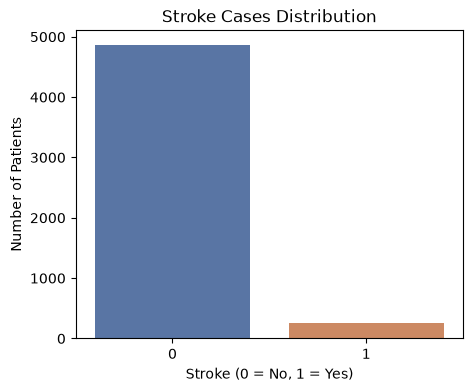

In [10]:
# Looking at it in a chart - how much imbalance is there
plt.figure(figsize=(5, 4))
sns.countplot(x="stroke", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Stroke Cases Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()


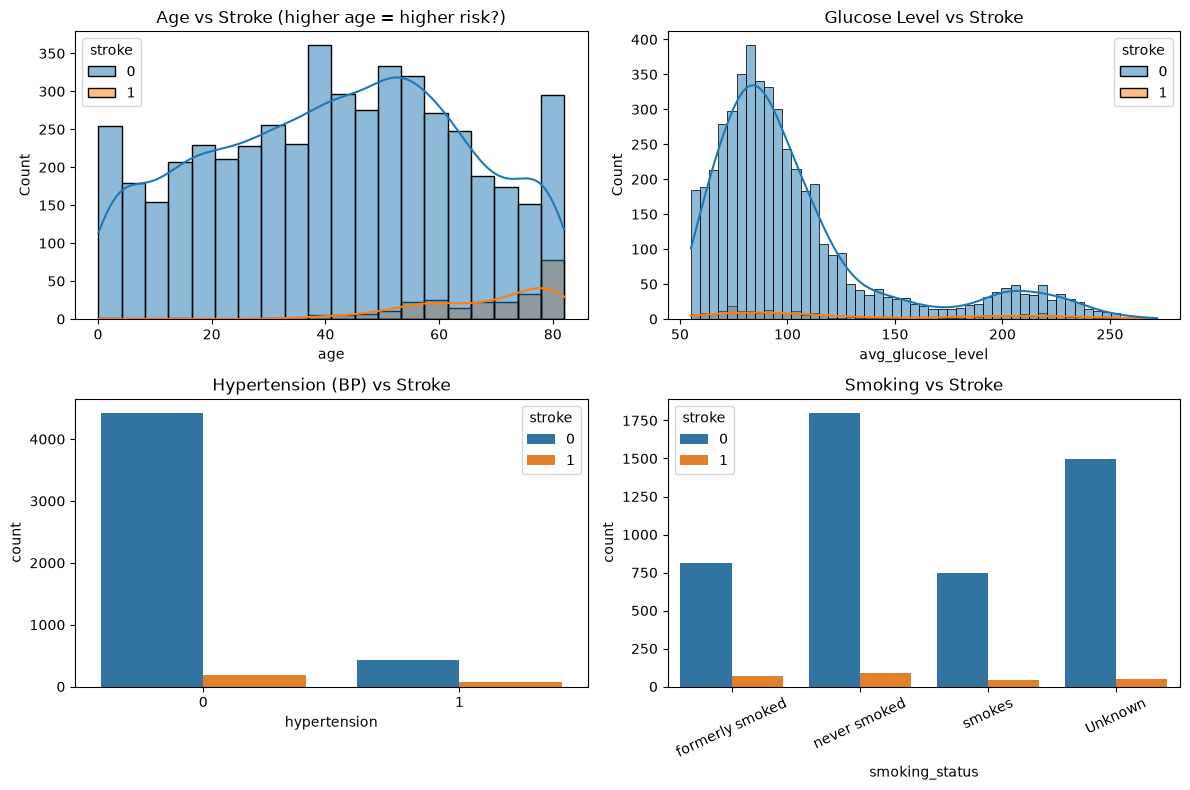

In [9]:
# Looking at the pattern of some important features - do they seem related to stroke?
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=df, x="age", hue="stroke", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age vs Stroke (higher age = higher risk?)")

sns.histplot(data=df, x="avg_glucose_level", hue="stroke", kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Glucose Level vs Stroke")

sns.countplot(data=df, x="hypertension", hue="stroke", ax=axes[1, 0])
axes[1, 0].set_title("Hypertension (BP) vs Stroke")

sns.countplot(data=df, x="smoking_status", hue="stroke", ax=axes[1, 1])
axes[1, 1].set_title("Smoking vs Stroke")
axes[1, 1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


**Observation:** There's a clear pattern in age and glucose level — the higher the age/glucose, the somewhat more common stroke is. This is a good sign — it means these features will be useful for the model.


## 4️⃣ Cleaning the Data + Train/Test Split

Now let's do some small cleaning:
- We'll drop the `id` column (it's just a number for each patient, no use for prediction)
- One row has `gender` as "Other" — since the count is so small, it's better to remove it
- Then we'll split the data into 2 parts: **train** (80% — the model will learn from this) and **test** (20% — we'll use this to check how well it learned)


In [11]:
# Dropping the id column
df = df.drop(columns=["id"])

# Dropping the row with 'Other' gender (only 1 row, negligible)
df = df[df["gender"] != "Other"]

# X = features (input), y = target (what we want to predict)
X = df.drop(columns=["stroke"])
y = df["stroke"]

print("Columns in Features (X):", list(X.columns))
print("Target (y):", "stroke")


Columns in Features (X): ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Target (y): stroke


In [12]:
# Splitting into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # keeping 20% of data for testing
    random_state=42,    # so we get the same split every time
    stratify=y          # important: so the stroke % stays the same in both train and test
)

print("Training data:", X_train.shape[0], "patients")
print("Testing data:", X_test.shape[0], "patients")


Training data: 4087 patients
Testing data: 1022 patients


## 5️⃣ Building the Preprocessing Pipeline

Now we need to make the data "understandable" for the model. There are two types of columns:

**Numeric columns** (age, avg_glucose_level, bmi):
- Fill missing values with the **median** (middle value)
- Then **scale** them (bring all numbers into a similar range)

**Categorical columns** (gender, work_type, smoking_status, etc.):
- Fill missing values with the **most common value**
- Then do **One-Hot Encoding** (convert text into 0/1 columns, since the model doesn't understand text)

`ColumnTransformer` does both of these together, applied to the right columns — think of it as a "recipe" that says what to do with each column.


In [13]:
# Which columns are numeric, which are categorical
numeric_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = ["gender", "hypertension", "heart_disease", "ever_married",
                         "work_type", "Residence_type", "smoking_status"]

# Recipe for numeric columns: fill missing -> scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fill missing values with the median
    ("scaler", StandardScaler())                      # bring numbers into the same range
])

# Recipe for categorical columns: fill missing -> encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill missing with the most common value
    ("onehot", OneHotEncoder(handle_unknown="ignore"))      # convert text into numbers (0/1)
])

# Combining both recipes - this defines which recipe applies to which column
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline ready!")


Preprocessing pipeline ready!


## 6️⃣ Fixing the Imbalance — SMOTE

Remember we saw that only ~5% of patients have had a stroke? Now we'll use **SMOTE**.

**Simple analogy:** Imagine you have 950 pictures of "No Stroke" and only 50 of "Stroke". If you train a model like this as-is, it'll get into the habit of saying "No Stroke" because it sees that much more. SMOTE creates new, similar (synthetic) examples of the minority class (Stroke) so both classes become equal — making the training fair.

**Important:** We'll apply SMOTE only on the **training data**. We'll leave the test data exactly as it is (real, unbalanced) — because in the real world too, data will be this imbalanced, and that's what we want to test against.


## 7️⃣ Training the Algorithms

Now we'll try **6 different algorithms** — each has its own way of finding patterns. First we'll look at one algorithm (Logistic Regression) in detail to see how the pipeline works, then we'll repeat the same process for the other 5 (using a loop, so we don't have to write the code again and again).

**Each algorithm's pipeline will follow these 3 steps:**
1. Preprocessing (which we built)
2. SMOTE (fixing the imbalance)
3. Model training


### First, an example — Logistic Regression

In [14]:
# Let's build one model step by step, so the pattern is clear

# 1. Choosing the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Building the full pipeline: preprocessing -> SMOTE -> model
log_reg_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", log_reg)
])

# 3. Fitting (training) on the training data
log_reg_pipeline.fit(X_train, y_train)

# 4. Predicting on the test data
y_pred = log_reg_pipeline.predict(X_test)

print("Logistic Regression trained!")
print("Test accuracy:", accuracy_score(y_test, y_pred))


Logistic Regression trained!
Test accuracy: 0.7338551859099804


C:\Users\Waseem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Waseem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Waseem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32


See that? Just 4 simple steps: **choose model → build pipeline → fit → predict**.

Now let's repeat the same pattern for the other 5 algorithms. Each algorithm's name and a simple explanation of how it thinks is given below:

| Algorithm | How it thinks (simple) |
|---|---|
| Decision Tree | Asks if-else style questions ("age > 50? then...") |
| Random Forest | Builds many Decision Trees and takes their "vote" |
| KNN | Looks at the most "similar" past patients to the new patient |
| SVM | Finds the best possible line/boundary between the two classes |
| XGBoost | Builds small trees one after another, each new tree fixing the previous one's mistakes |


In [15]:
# Now let's put all 6 models into a dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

print("These", len(models), "algorithms will be trained:")
for name in models:
    print(" -", name)


These 6 algorithms will be trained:
 - Logistic Regression
 - Decision Tree
 - Random Forest
 - KNN
 - SVM
 - XGBoost


In [16]:
# Now let's train each model in a loop using the same 4-step process
# (this is the same thing we did manually above for Logistic Regression,
#  but now using a loop instead of writing it again for every model)

results = []            # each model's score will be stored here
trained_pipelines = {}  # each model's trained pipeline will be stored here (for later use)

for name, model in models.items():
    print(f"Training: {name} ...")

    # Step 1+2: building the full pipeline
    full_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", model)
    ])

    # Step 3: training
    full_pipeline.fit(X_train, y_train)
    trained_pipelines[name] = full_pipeline

    # Step 4: predicting on test data + computing scores
    y_pred = full_pipeline.predict(X_test)
    y_pred_proba = full_pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    })

print("\nAll 6 models trained!")


Training: Logistic Regression ...
Training: Decision Tree ...
Training: Random Forest ...
Training: KNN ...
Training: SVM ...


C:\Users\Waseem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training: XGBoost ...

All 6 models trained!


## 8️⃣ Comparing All Models

Now let's see which algorithm is performing the best.

**Which metric matters most here?**
In healthcare, **Recall** matters the most — because if the model says "No Stroke" for a real stroke case (false negative), that can be dangerous. So we'll sort by Recall.


In [17]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)

# Rounding all numbers to 3 decimal places, for easier viewing
results_df.round(3)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.734,0.132,0.80,0.227,0.839
1,SVM,0.795,0.112,0.46,0.180,0.765
2,KNN,0.823,0.098,0.32,0.150,0.651
3,Decision Tree,0.883,0.111,0.20,0.143,0.559
4,XGBoost,0.926,0.175,0.14,0.156,0.775
5,Random Forest,0.932,0.172,0.10,0.127,0.763


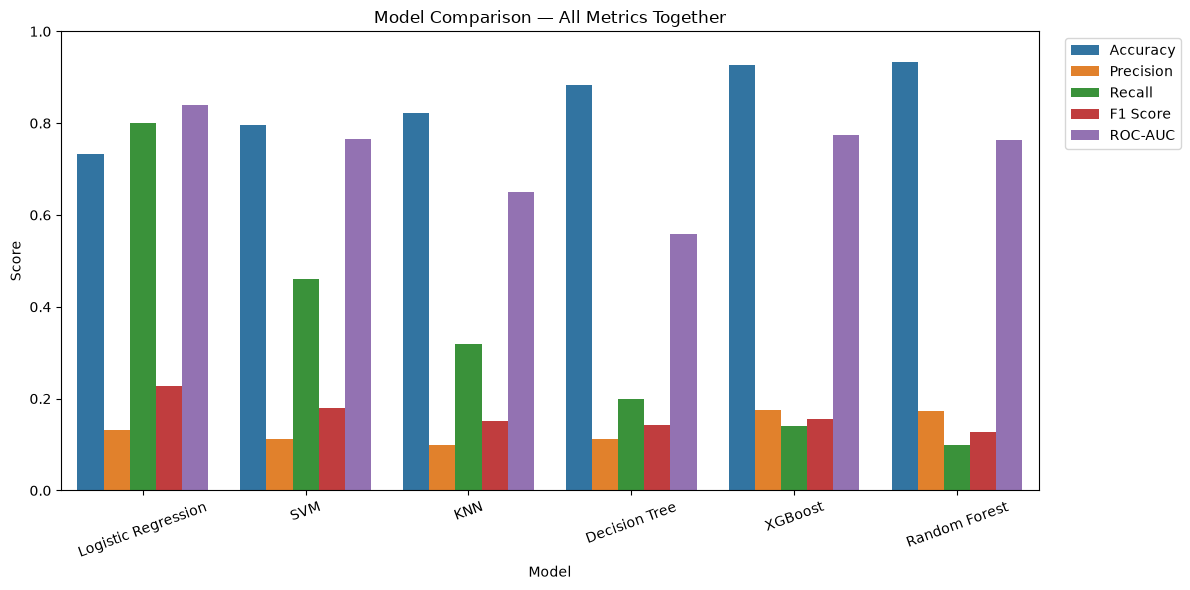

In [18]:
# Viewing the comparison in a bar chart - all metrics together
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison — All Metrics Together")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### What Is a Confusion Matrix? (Simple Explanation)

A confusion matrix is a 2x2 table that shows:
- How many "No Stroke" cases the model correctly caught
- How many "Stroke" cases the model correctly caught
- How many mistakes the model made (wrongly said "Stroke", or wrongly said "No Stroke")

Let's look at each model's confusion matrix below.


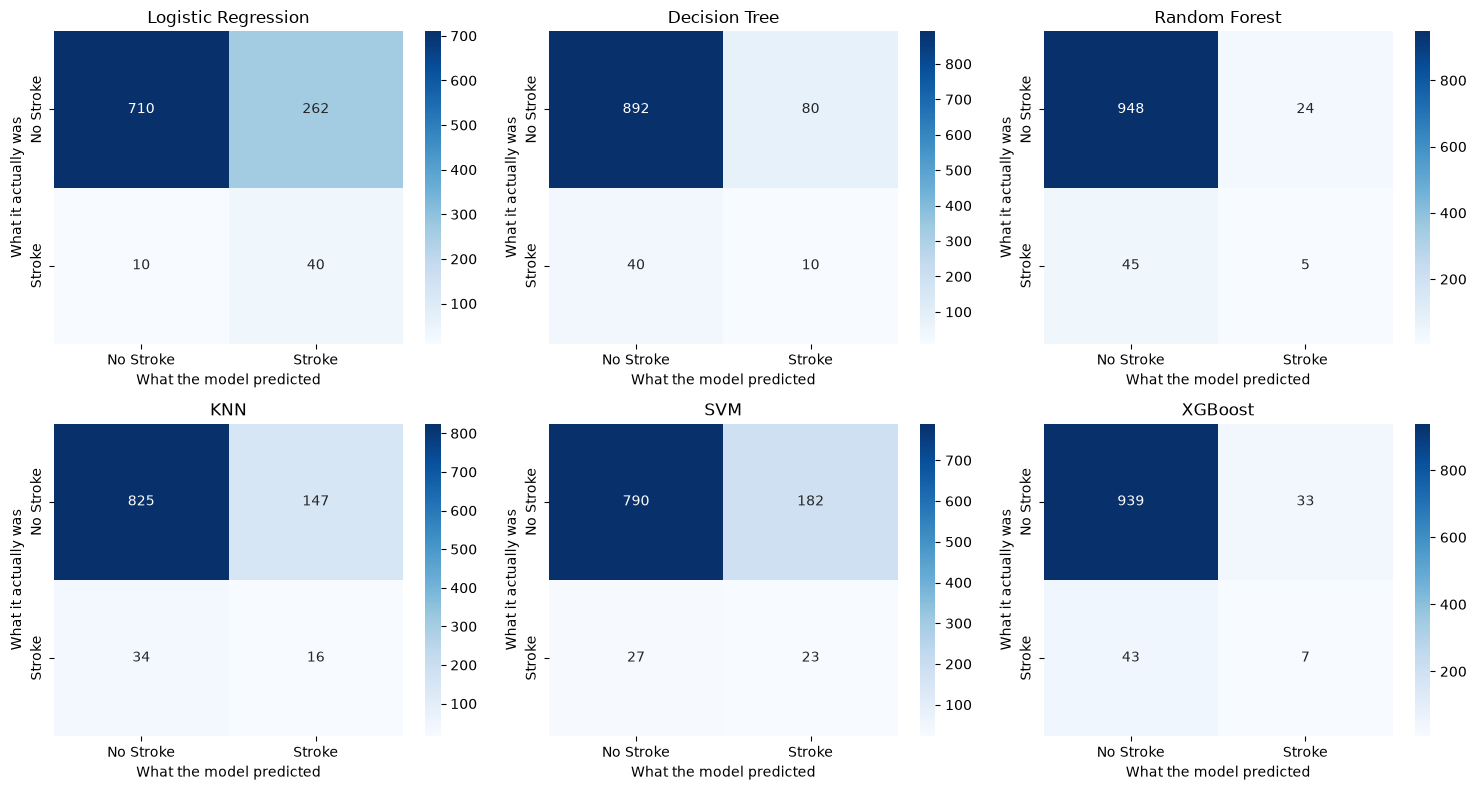

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, (name, pipeline) in enumerate(trained_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"])
    axes[idx].set_title(name)
    axes[idx].set_xlabel("What the model predicted")
    axes[idx].set_ylabel("What it actually was")

plt.tight_layout()
plt.show()


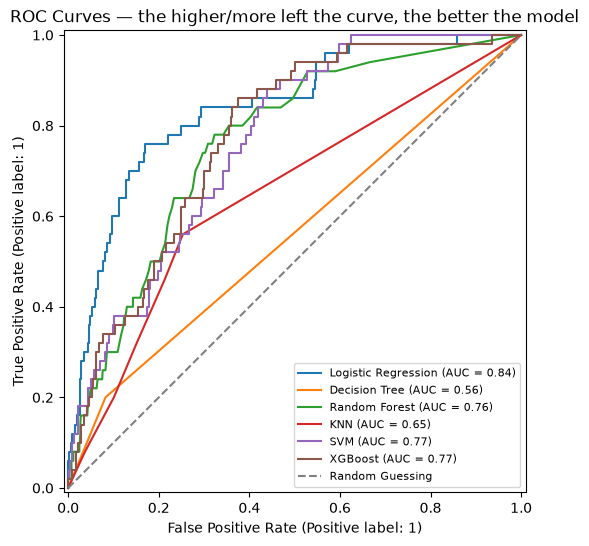

In [20]:
# ROC curves - comparing all models on one graph
plt.figure(figsize=(8, 6))
for name, pipeline in trained_pipelines.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, name=name, ax=plt.gca())

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guessing")
plt.title("ROC Curves — the higher/more left the curve, the better the model")
plt.legend(fontsize=8)
plt.show()


## 9️⃣ Saving the Best Model

The first row of the `results_df` table (which we sorted by Recall) is our best model. Now we'll save the whole pipeline (preprocessing + SMOTE + model, all together) into one file — so it can simply be loaded and used directly in the Streamlit app.


In [21]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model (by Recall):", best_model_name)
print()
print(results_df.iloc[0])


Best model (by Recall): Logistic Regression

Model        Logistic Regression
Accuracy                0.733855
Precision                0.13245
Recall                       0.8
F1 Score                0.227273
ROC-AUC                 0.838971
Name: 0, dtype: object


In [ ]:
# Saving the entire pipeline to a file
joblib.dump(best_pipeline, "best_stroke_model.pkl")
print("Model saved: best_stroke_model.pkl")
print("\nThis file contains everything - preprocessing + SMOTE + the trained model -")
print("In the Streamlit app, I just need to load it, no separate preprocessing needed.")


NameError: name 'best_pipeline' is not defined

In [ ]:
# Looking at the best model's detailed report
y_pred_best = best_pipeline.predict(X_test)
print(f"===== {best_model_name} — Detailed Report =====\n")
print(classification_report(y_test, y_pred_best, target_names=["No Stroke", "Stroke"]))


---
## ✅ Recap — What Did We Learn?

1. Loading data and understanding it through EDA
2. Recognizing imbalanced data and handling it with SMOTE
3. Building a clean, reusable preprocessing pipeline with `ColumnTransformer`
4. Training 6 different algorithms and comparing them fairly
5. Choosing the right metric (Recall) instead of relying only on Accuracy
6. Saving the whole pipeline for deployment

